In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [32]:
import pandas as pd

url = "https://www.statlearning.com/s/Advertising.csv"

df = pd.read_csv(url)

df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [33]:
df.shape

(200, 5)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [35]:
df.isnull().sum()

,0
Unnamed: 0,0
TV,0
radio,0
newspaper,0
sales,0


In [36]:
df.describe()

,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


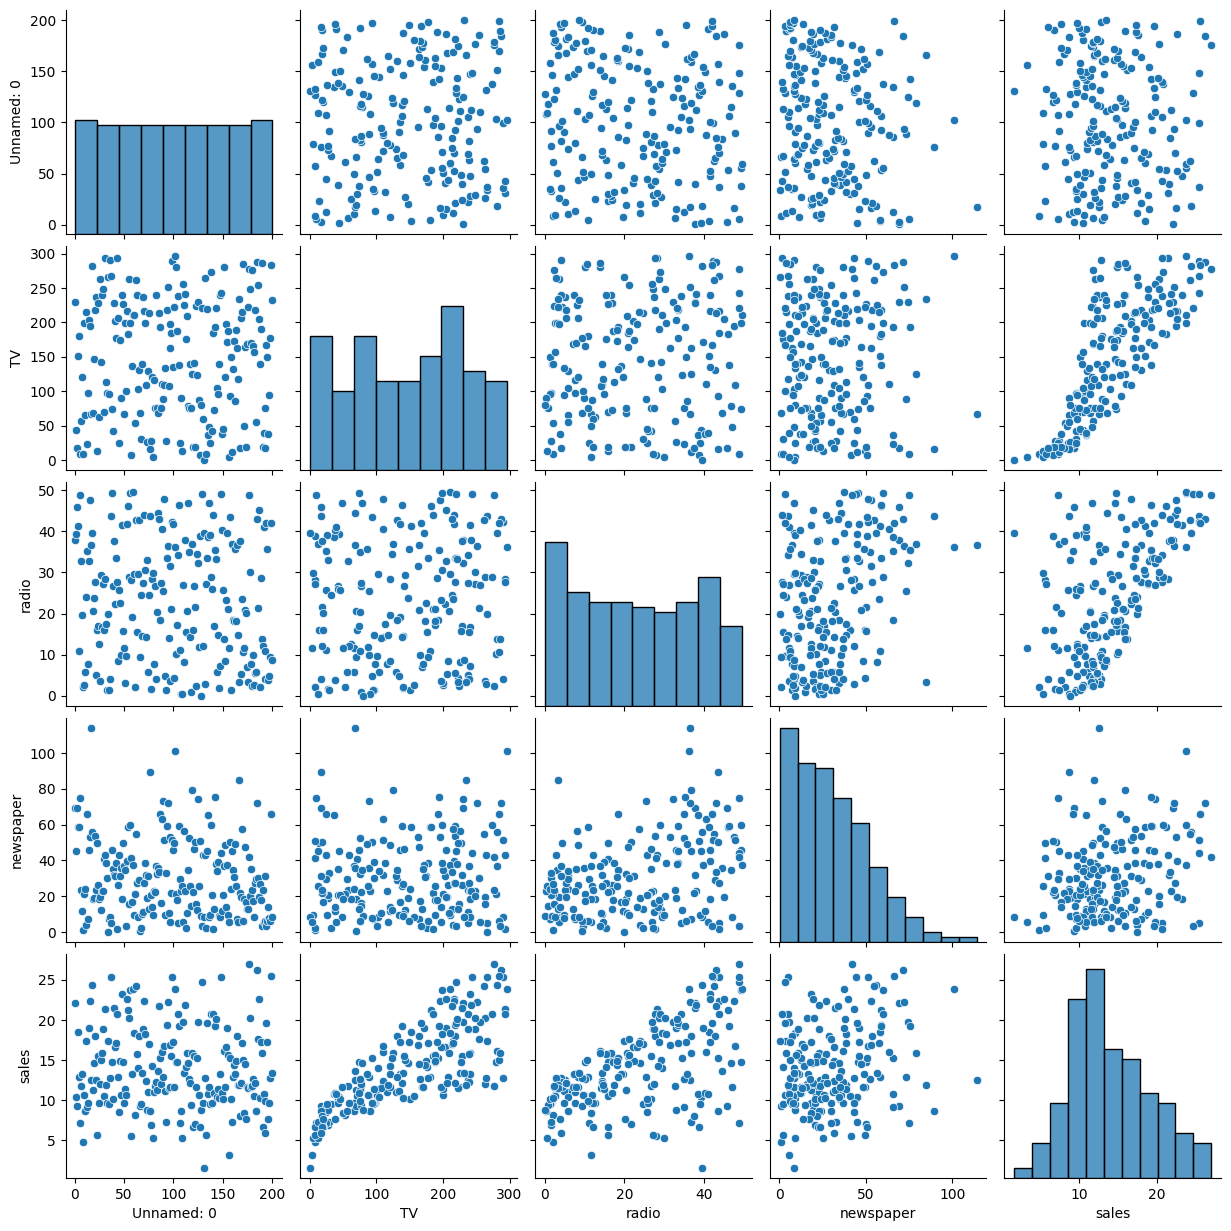

In [37]:
sns.pairplot(df)
plt.show()

In [38]:
print(df.head())
print(df.columns)
print(df.shape)

   Unnamed: 0     TV  radio  newspaper  sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9
Index(['Unnamed: 0', 'TV', 'radio', 'newspaper', 'sales'], dtype='object')
(200, 5)


In [39]:
print(df.columns.tolist())

['Unnamed: 0', 'TV', 'radio', 'newspaper', 'sales']


In [40]:
print(df.columns.tolist())

['Unnamed: 0', 'TV', 'radio', 'newspaper', 'sales']


In [41]:
df = df.drop(columns=["Unnamed: 0"])

df = df.rename(columns={
    "radio": "Radio",
    "newspaper": "Newspaper",
    "sales": "Sales"
})

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


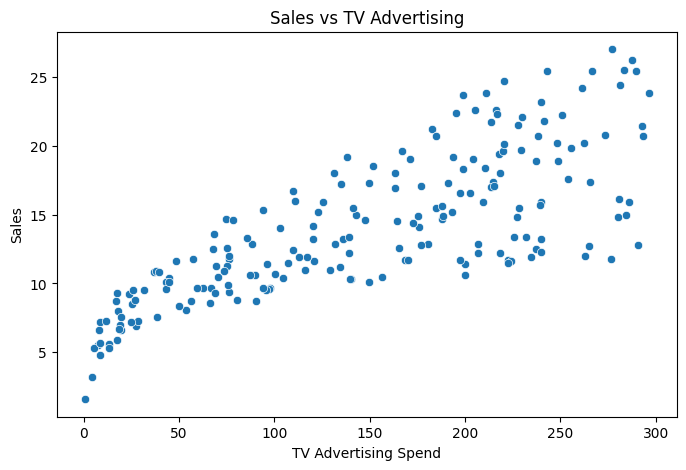

In [42]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="TV", y="Sales")

plt.title("Sales vs TV Advertising")
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")
plt.show()

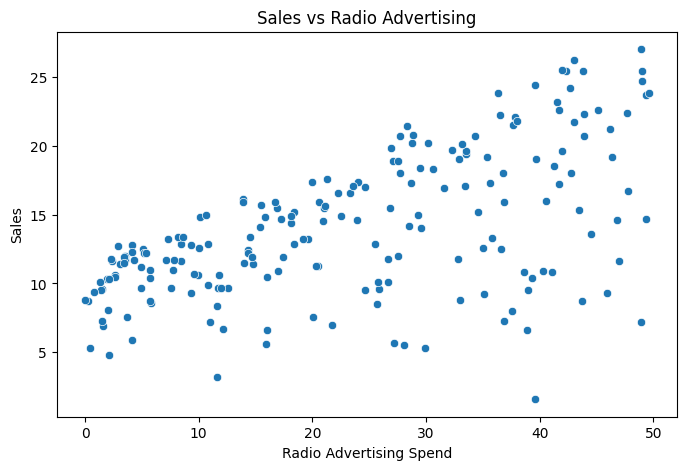

In [43]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Radio", y="Sales")

plt.title("Sales vs Radio Advertising")
plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")
plt.show()

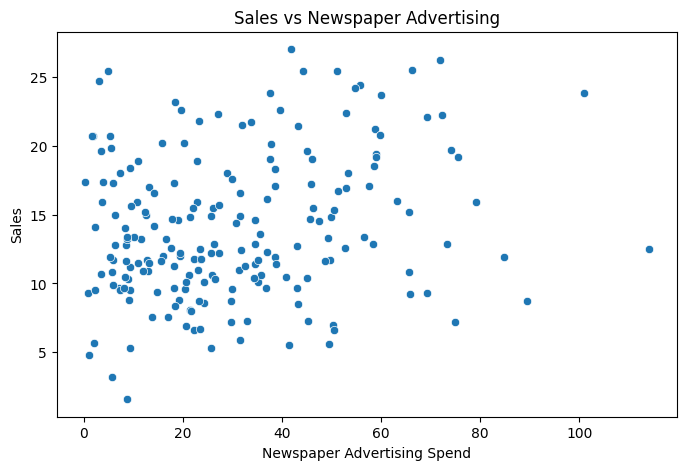

In [44]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Newspaper", y="Sales")

plt.title("Sales vs Newspaper Advertising")
plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Sales")
plt.show()

In [45]:
correlation = df.corr()

correlation

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


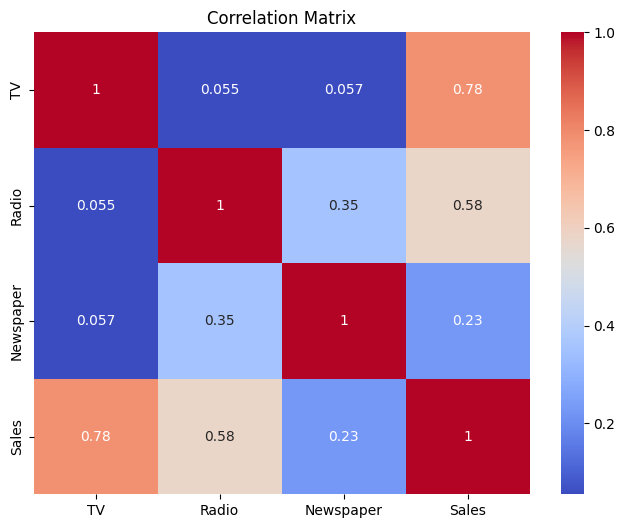

In [46]:
plt.figure(figsize=(8, 6))

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

In [47]:
X = df[["TV", "Radio", "Newspaper"]]

y = df["Sales"]

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [49]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

LinearRegression()

In [50]:
y_pred_linear = linear_model.predict(X_test)

In [51]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2

In [52]:
mae_linear, rmse_linear, r2_linear = evaluate_model(
    y_test, y_pred_linear
)

print("Linear Regression")
print("MAE:", mae_linear)
print("RMSE:", rmse_linear)
print("R² Score:", r2_linear)

Linear Regression
MAE: 1.4607567168117603
RMSE: 1.78159966153345
R² Score: 0.899438024100912


In [53]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

coefficients

,Feature,Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


In [54]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [55]:
y_pred_rf = rf_model.predict(X_test)

In [56]:
mae_rf, rmse_rf, r2_rf = evaluate_model(
    y_test, y_pred_rf
)

print("Random Forest Regression")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Random Forest Regression
MAE: 0.6200999999999988
RMSE: 0.7685910811348248
R² Score: 0.9812843792541843


In [57]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_linear, mae_rf],
    "RMSE": [rmse_linear, rmse_rf],
    "R2 Score": [r2_linear, r2_rf]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest,0.620100,0.768591,0.981284


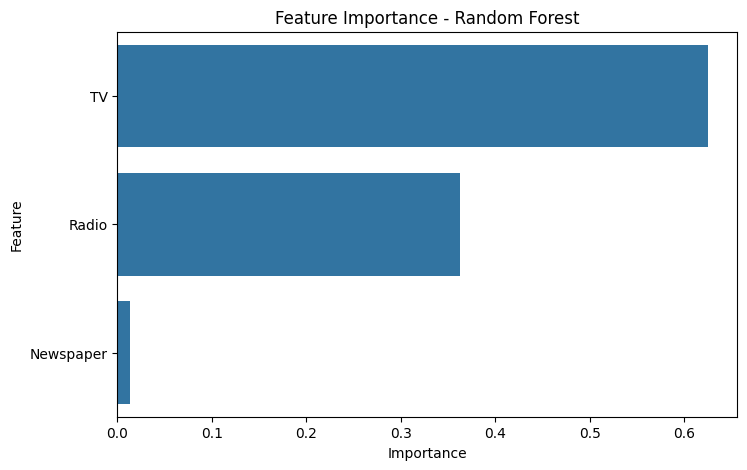

In [58]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance
plt.figure(figsize=(8, 5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")
plt.show()

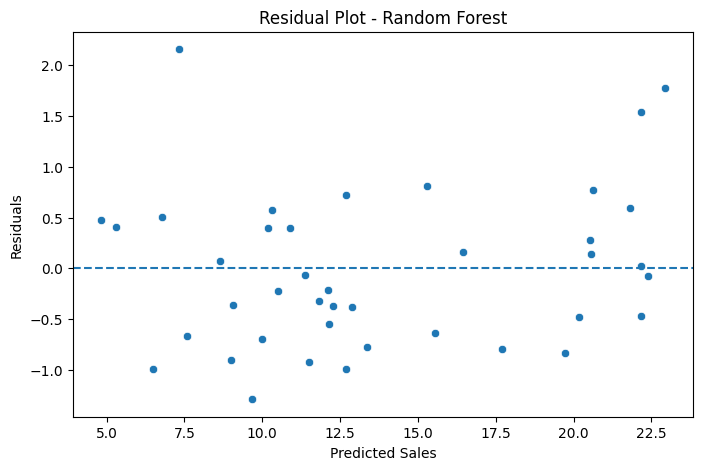

In [59]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_pred_rf,
    y=residuals
)

plt.axhline(y=0, linestyle="--")

plt.title("Residual Plot - Random Forest")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.show()

## Conclusion

Two regression models were trained to predict sales:
Linear Regression and Random Forest Regression.

Both models were evaluated using MAE, RMSE, and R² score.

The model with the lowest MAE and RMSE and the highest R² score was considered the best-performing model.

Feature coefficients from Linear Regression and feature importance from Random Forest were used to identify the advertising channel with the greatest impact on sales.

The results show that TV advertising has the strongest relationship with sales compared with Radio and Newspaper advertising.